In [28]:


import sys
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns 


from sklearn.cluster import AgglomerativeClustering, KMeans , DBSCAN
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import StandardScaler , OneHotEncoder , FunctionTransformer

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score



from sklearn.decomposition import PCA 

sys.path.append(os.path.abspath('..'))

from src import CATEGORICAL_COLUMNS , loader , NUMERICAL_COLUMNS , DROP_COLUMNS , BINARY_COLUMNS , GENDER_COLUMNS
df =  loader()


In [29]:
binary_encoding = FunctionTransformer(lambda x: x.replace({'Yes' : 1, 'No' : 0}) , feature_names_out='one-to-one')
gender_encoding = FunctionTransformer(lambda x: x.replace({'Male' : 1, 'Female' : 0}) , feature_names_out='one-to-one')


preprocessor = ColumnTransformer([
    ('numerical', Pipeline([
        ('imputer' , SimpleImputer(strategy='mean')) , 
        ('scaler' , StandardScaler()) 
    ]) , NUMERICAL_COLUMNS ) , 
    ('categorical' , Pipeline([
        ('imputer' , SimpleImputer(strategy='most_frequent') ) , 
        ('encoding', OneHotEncoder(handle_unknown='ignore' , sparse_output=False)) 
    ]), CATEGORICAL_COLUMNS ) ,
    ('binary' , Pipeline([
        ('encoding' , binary_encoding)
    ]), BINARY_COLUMNS ),
    ('gender' , Pipeline([
        ('encoding' , gender_encoding)
    ]), GENDER_COLUMNS )] , 
    remainder='drop'
)

df_preproce = preprocessor.fit_transform(df)

df_preproce = pd.DataFrame(
    df_preproce,
    columns=preprocessor.get_feature_names_out() , 
    index=df.index
)

df_preproce.head()



,numerical__tenure,numerical__MonthlyCharges,numerical__TotalCharges,categorical__MultipleLines_No,categorical__MultipleLines_No phone service,categorical__MultipleLines_Yes,categorical__InternetService_DSL,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__OnlineSecurity_No,...,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,binary__SeniorCitizen,binary__Partner,binary__Dependents,binary__PhoneService,binary__PaperlessBilling,gender__gender
0,-1.277445,-1.160323,-0.994971,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0,1,0,0,1,0
1,0.066327,-0.259629,-0.173876,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0,0,0,1,0,1
2,-1.236724,-0.36266,-0.960399,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0,0,0,1,1,1
3,0.514251,-0.746535,-0.1954,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0,0,0,0,0,1
4,-1.236724,0.197365,-0.941193,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0,0,0,1,1,0


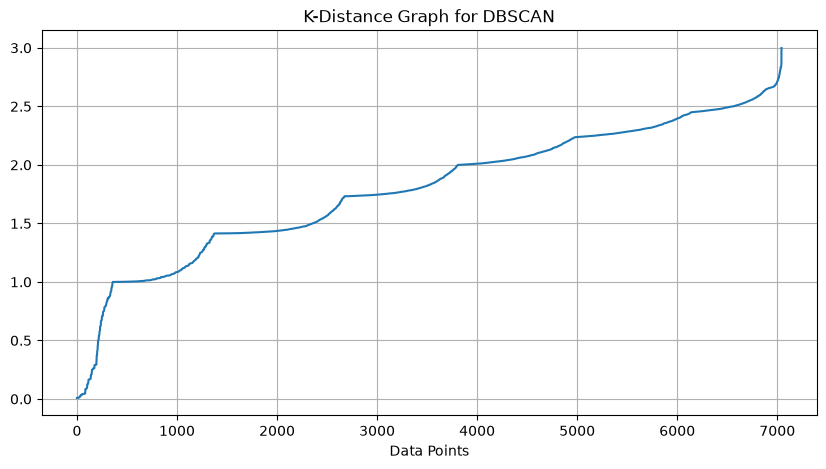

clusters: 2
noise %: 0.01419849495953429


In [39]:
K = 20
nn = NearestNeighbors(n_neighbors=K) 
distances, indices = nn.fit(df_preproce).kneighbors()

kdist = np.sort(distances[:, K-1])

plt.figure(figsize=(10, 5))
plt.plot(kdist)
plt.title('K-Distance Graph for DBSCAN')
plt.xlabel('Data Points')
plt.grid() 

plt.show()

print("clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("noise %:", (labels == -1).mean() * 100)

In [ ]:
# eps_values = [1.4, 1.5, 1.8, 2.0, 2.2, 2.4, 2.5]
# min_samples_values = [3, 5, 7, 10]


# for eps in eps_values:
#     for min_samples in min_samples_values:
#         dbscan = DBSCAN(
#             eps=eps,
#             min_samples=min_samples
#         )
    
#         labels = dbscan.fit_predict(df_preproce)

#         n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
#         noise_pct = (labels == -1).mean() * 100

#         print(
#             f"eps={eps} | "
#             f"clusters={n_clusters} | "
#             f"min_samples={min_samples} | "
#             f"noise={noise_pct:.2f}%"
#         )
        

eps=1.4 | clusters=281 | min_samples=3 | noise=42.81%
eps=1.4 | clusters=130 | min_samples=5 | noise=52.21%
eps=1.4 | clusters=83 | min_samples=7 | noise=57.48%
eps=1.4 | clusters=56 | min_samples=10 | noise=61.98%
eps=1.5 | clusters=78 | min_samples=3 | noise=25.37%
eps=1.5 | clusters=22 | min_samples=5 | noise=32.95%
eps=1.5 | clusters=7 | min_samples=7 | noise=37.87%
eps=1.5 | clusters=6 | min_samples=10 | noise=41.94%
eps=1.8 | clusters=41 | min_samples=3 | noise=9.24%
eps=1.8 | clusters=14 | min_samples=5 | noise=14.64%
eps=1.8 | clusters=8 | min_samples=7 | noise=18.88%
eps=1.8 | clusters=4 | min_samples=10 | noise=23.94%
eps=2.0 | clusters=16 | min_samples=3 | noise=4.87%
eps=2.0 | clusters=13 | min_samples=5 | noise=8.25%
eps=2.0 | clusters=5 | min_samples=7 | noise=11.91%
eps=2.0 | clusters=6 | min_samples=10 | noise=16.24%
eps=2.2 | clusters=2 | min_samples=3 | noise=0.50%
eps=2.2 | clusters=2 | min_samples=5 | noise=0.74%
eps=2.2 | clusters=3 | min_samples=7 | noise=1.31%
ep

In [32]:
# silhouette = []
# wc = []
# k_range = range(2, 11)
# for k in k_range:
#     model = KMeans(n_clusters=k, random_state=42)
#     labels = model.fit_predict(df_preproce)


#     wc.append(model.inertia_)
#     silhouette_avg = silhouette_score(df_preproce, labels)
#     silhouette.append(silhouette_avg)


In [33]:
# fig , axes = plt.subplots(1, 2, figsize=(15, 5 ))

# sns.lineplot(x=k_range, y=silhouette , marker='o', linewidth=2, ax=axes[0])
# plt.title('Silhouette Score vs Number of Clusters')
# plt.xlabel('Number of Clusters')
# plt.ylabel('Silhouette Score')

# sns.lineplot(x=k_range, y=wc, marker='o', linewidth=2, ax=axes[1])
# plt.xlabel('Number of Clusters')
# plt.ylabel('WCSS')

In [34]:

kmeans = Pipeline([
    ('preprocessor', preprocessor ) , 
    ('kmeans' , KMeans(n_clusters=3 , random_state=42) )
])

db_scan = Pipeline([
    ('preprocessor', preprocessor ) ,
    ('dbscan' , DBSCAN(eps=2.2, min_samples=7))
])

aggo = Pipeline([
    ('preprocessor', preprocessor ) ,
    ('agglo' , AgglomerativeClustering(n_clusters=3 , linkage='ward' ) )
])

pca = PCA(n_components=2) 

df_pca = pca.fit_transform(df_preproce)


In [35]:
model = kmeans.fit(df)
labels_kmeans = model.named_steps['kmeans'].labels_  

pd.Series(labels_kmeans).value_counts().sort_index()

0    3198
1    2319
2    1526
Name: count, dtype: int64

In [36]:

dbscan_model = db_scan.fit(df)
labels_dbscan = dbscan_model.named_steps['dbscan'].labels_

pd.Series(labels_dbscan).value_counts().sort_index()

-1      92
 0    5422
 1    1526
 2       3
Name: count, dtype: int64

In [37]:
aggo_model = aggo.fit(df)
labels_aggo = aggo_model.named_steps['agglo'].labels_

pd.Series(labels_aggo).value_counts().sort_index()

0    3556
1    1526
2    1961
Name: count, dtype: int64

Text(0.5, 1.0, 'Agglomerative Clustering')

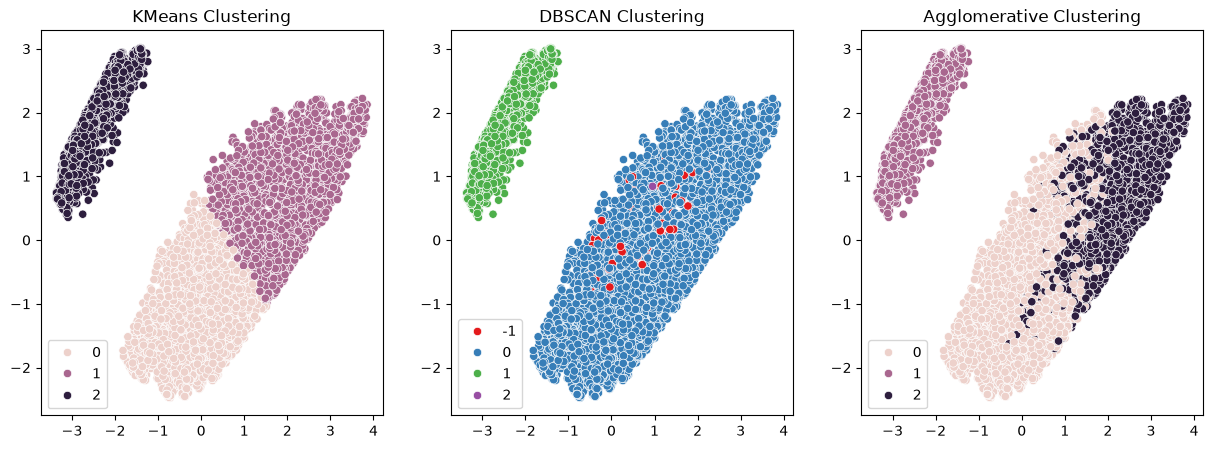

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(x=df_pca[:, 0] , y=df_pca[:, 1], hue=labels_kmeans, ax=axes[0])
axes[0].set_title('KMeans Clustering')

sns.scatterplot(x=df_pca[:, 0] , y=df_pca[:, 1], hue=labels_dbscan, ax=axes[1] , palette='Set1')
axes[1].set_title('DBSCAN Clustering')

sns.scatterplot(x=df_pca[:, 0] , y=df_pca[: , 1] , hue=labels_aggo , ax=axes[2]  ) ;
axes[2].set_title('Agglomerative Clustering')